In [1]:
import os


os.environ['KAGGLE_USERNAME'] = "shivanisrim23adr149"
os.environ['KAGGLE_KEY'] = "KGAT_8401b1502ac40a1f39d72732364623c7"


print("Downloading dataset from Kaggle...")
!pip install -q kaggle
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


print("Unzipping dataset (this takes about 1-2 minutes)...")
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset/
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:01<00:00, 90.1MB/s]

Unzipping dataset (this takes about 1-2 minutes)...
Dataset ready!


In [2]:
import pandas as pd
import numpy as np
import os
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("Loading dataset...")
# Map all image names to their exact unzipped path in Colab
image_paths = {os.path.splitext(os.path.basename(x))[0]: x for x in glob(os.path.join('dataset', '*', '*.jpg'))}

# Load CSV
df = pd.read_csv('dataset/HAM10000_metadata.csv')
df['image_path'] = df['image_id'].map(image_paths.get)

# Drop any rows where the image wasn't found
df = df.dropna(subset=['image_path'])
print(f"Valid images found: {len(df)}")

# Create Binary Labels (Malignant vs Benign)
MALIGNANT = ['mel', 'bcc', 'akiec']
df['binary_label'] = df['dx'].apply(lambda x: 'malignant' if x in MALIGNANT else 'benign')

print("\nDataset Distribution:")
print(df['binary_label'].value_counts())

# Train/Val Split (80% Train, 20% Val)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['binary_label'], random_state=42
)

Loading dataset...
Valid images found: 10015

Dataset Distribution:
binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Data Augmentation for training
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
# Only rescale for validation
val_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_dataframe(
    train_df, x_col="image_path", y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=True
)

val_ds = val_gen.flow_from_dataframe(
    val_df, x_col="image_path", y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=False
)

# Compute Class Weights (forces the model to pay attention to minority classes)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['binary_label']),
    y=train_df['binary_label']
)
class_indices = train_ds.class_indices
class_weight_dict = {
    class_indices['benign']: class_weights_array[0],
    class_indices['malignant']: class_weights_array[1]
}
print("\nClass Weights:", class_weight_dict)

Found 8012 validated image filenames belonging to 2 classes.
Found 2003 validated image filenames belonging to 2 classes.

Class Weights: {0: np.float64(0.6211815785393084), 1: np.float64(2.563019833653231)}


In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_model(base_model_func, model_name):
    # Load pre-trained base model
    base = base_model_func(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = True # Unfreeze layers for fine-tuning

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x) # Sigmoid for binary output (0 to 1)

    model = Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Tiny learning rate for fine-tuning
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # AUC is best for imbalanced medical data
    )
    return model

models_to_test = {
    "EfficientNetB0": EfficientNetB0,
    "ResNet50": ResNet50,
    "MobileNetV2": MobileNetV2
}

histories = {}
results = {}
EPOCHS = 10

for name, model_func in models_to_test.items():
    print(f"\n======================================")
    print(f"        TRAINING {name}         ")
    print(f"======================================")

    model = build_model(model_func, name)

    # Save the best model locally in Colab
    checkpoint_path = f"best_{name}_binary.h5"

    early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_auc", mode="max", save_best_only=True)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    histories[name] = history.history
    loss, acc, auc = model.evaluate(val_ds, verbose=0)
    results[name] = {"Accuracy": acc, "AUC": auc}
    print(f"\n[Finished {name}] -> Val Acc: {acc:.4f} | Val AUC: {auc:.4f}\n")


        TRAINING EfficientNetB0         
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.4975 - auc: 0.6483 - loss: 0.6704

251/251 ━━━━━━━━━━━━━━━━━━━━ 329s 948ms/step - accuracy: 0.5625 - auc: 0.7109 - loss: 0.6314 - val_accuracy: 0.2087 - val_auc: 0.4710 - val_loss: 0.7107
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.6730 - auc: 0.7964 - loss: 0.5598

251/251 ━━━━━━━━━━━━━━━━━━━━ 169s 675ms/step - accuracy: 0.6877 - auc: 0.8189 - loss: 0.5279 - val_accuracy: 0.5637 - val_auc: 0.5906 - val_loss: 0.6671
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7189 - auc: 0.8488 - loss: 0.4764

251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 639ms/step - accuracy: 0.7247 - auc: 0.8512 - loss: 0.4726 - val_accuracy: 0.4164 - val_auc: 0.7157 - val_loss: 0.7170
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.7380 - auc: 0.8640 - loss: 0.4486

251/251 ━━━━━━━━━━━━━━━━━━━━ 161s 642ms/step - accuracy: 0.7419 - auc: 0.8627 - loss: 0.4521 - val_accuracy: 0.7878 - val_auc: 0.8493 - val_loss: 0.4764
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 164s 652ms/step - accuracy: 0.7463 - auc: 0.8746 - loss: 0.4295 - val_accuracy: 0.8073 - val_auc: 0.8134 - val_loss: 0.4551
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 170s 677ms/step - accuracy: 0.7511 - auc: 0.8751 - loss: 0.4293 - val_accuracy: 0.8018 - val_auc: 0.6850 - val_loss: 0.5090
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 636ms/step - accuracy: 0.7626 - auc: 0.8814 - loss: 0.4202 - val_accuracy: 0.8283 - val_auc: 0.7396 - val_loss: 0.4317

[Finished EfficientNetB0] -> Val Acc: 0.7878 | Val AUC: 0.8493


        TRAINING ResNet50         
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.6023 - auc: 0.7134 - loss: 0.6315

...

251/251 ━━━━━━━━━━━━━━━━━━━━ 165s 654ms/step - accuracy: 0.7763 - auc: 0.8796 - loss: 0.4317 - val_accuracy: 0.8313 - val_auc: 0.8197 - val_loss: 0.4537
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7774 - auc: 0.8823 - loss: 0.4273

251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 638ms/step - accuracy: 0.7839 - auc: 0.8869 - loss: 0.4173 - val_accuracy: 0.8382 - val_auc: 0.8382 - val_loss: 0.4131
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.7905 - auc: 0.8903 - loss: 0.4179

251/251 ━━━━━━━━━━━━━━━━━━━━ 159s 632ms/step - accuracy: 0.7947 - auc: 0.8955 - loss: 0.4027 - val_accuracy: 0.8422 - val_auc: 0.8518 - val_loss: 0.3975
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.7995 - auc: 0.8997 - loss: 0.3926

251/251 ━━━━━━━━━━━━━━━━━━━━ 157s 623ms/step - accuracy: 0.8018 - auc: 0.9033 - loss: 0.3880 - val_accuracy: 0.8457 - val_auc: 0.8613 - val_loss: 0.3901
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7888 - auc: 0.8906 - loss: 0.4183

251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 621ms/step - accuracy: 0.7977 - auc: 0.9000 - loss: 0.3938 - val_accuracy: 0.8517 - val_auc: 0.8709 - val_loss: 0.3701

[Finished MobileNetV2] -> Val Acc: 0.8517 | Val AUC: 0.8709



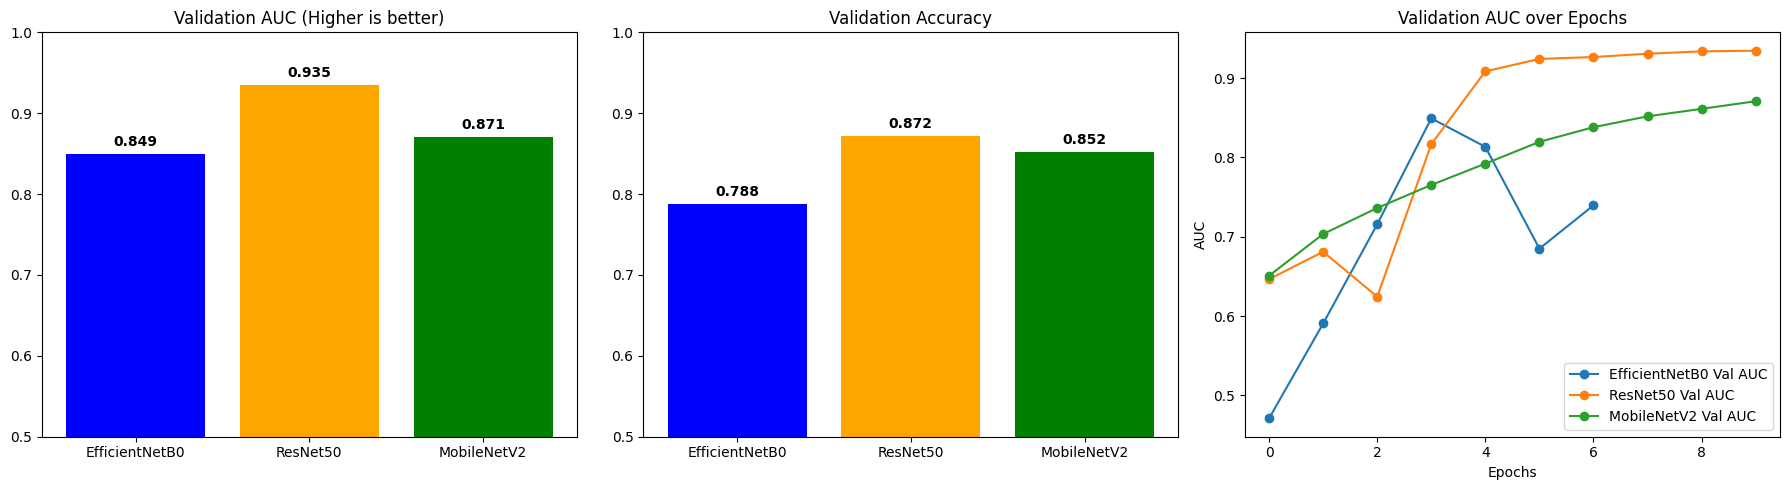

In [5]:
plt.figure(figsize=(18, 5))

# Plot 1: Validation AUC
plt.subplot(1, 3, 1)
names = list(results.keys())
aucs = [res["AUC"] for res in results.values()]
plt.bar(names, aucs, color=['blue', 'orange', 'green'])
plt.title('Validation AUC (Higher is better)')
plt.ylim(0.5, 1.0)
for i, v in enumerate(aucs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

# Plot 2: Validation Accuracy
plt.subplot(1, 3, 2)
accs = [res["Accuracy"] for res in results.values()]
plt.bar(names, accs, color=['blue', 'orange', 'green'])
plt.title('Validation Accuracy')
plt.ylim(0.5, 1.0)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

# Plot 3: Learning Curves (AUC over epochs)
plt.subplot(1, 3, 3)
for name, hist in histories.items():
    plt.plot(hist['val_auc'], marker='o', label=f"{name} Val AUC")
plt.title('Validation AUC over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
# 1. Filter dataset to ONLY Malignant images
mal_df = df[df['binary_label'] == 'malignant'].copy()

# 2. Train/Val Split for Malignant
from sklearn.model_selection import train_test_split
train_mal, val_mal = train_test_split(
    mal_df, test_size=0.2, stratify=mal_df['dx'], random_state=42
)

# 3. Image Generators (3 Classes)
train_mal_ds = train_gen.flow_from_dataframe(
    train_mal, x_col="image_path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="categorical",
    batch_size=BATCH_SIZE, shuffle=True
)
val_mal_ds = val_gen.flow_from_dataframe(
    val_mal, x_col="image_path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="categorical",
    batch_size=BATCH_SIZE, shuffle=False
)

# 4. Build and Train Model
print("Building Malignant Sub-Classifier...")
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

base_mal = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mal.trainable = True

x = GlobalAveragePooling2D()(base_mal.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out_mal = Dense(3, activation='softmax')(x) # 3 Malignant Classes!

model_malignant = Model(inputs=base_mal.input, outputs=out_mal)
import tensorflow as tf
model_malignant.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
print("Training Malignant Sub-Classifier...")
model_malignant.fit(train_mal_ds, validation_data=val_mal_ds, epochs=10,
                    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
model_malignant.save("hierarchical_malignant_model.h5")
print("Saved Malignant Model!")

Found 1563 validated image filenames belonging to 3 classes.
Found 391 validated image filenames belonging to 3 classes.
Building Malignant Sub-Classifier...
Training Malignant Sub-Classifier...
Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.3749 - loss: 1.1342 - val_accuracy: 0.1662 - val_loss: 1.2614
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 617ms/step - accuracy: 0.5016 - loss: 1.0167 - val_accuracy: 0.1662 - val_loss: 1.2444
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 618ms/step - accuracy: 0.5534 - loss: 0.9651 - val_accuracy: 0.1662 - val_loss: 1.2201
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 32s 644ms/step - accuracy: 0.5829 - loss: 0.9008 - val_accuracy: 0.1714 - val_loss: 1.1430
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 620ms/step - accuracy: 0.6187 - loss: 0.8517 - val_accuracy: 0.5396 - val_loss: 1.0179
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 671ms/step - accuracy: 0.6225 - loss: 0.8247 - val_accuracy: 0.4373 - val_loss: 1.0502
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━

Saved Malignant Model!


In [7]:
# 1. Filter dataset to ONLY Benign images
ben_df = df[df['binary_label'] == 'benign'].copy()

# 2. Train/Val Split for Benign
train_ben, val_ben = train_test_split(
    ben_df, test_size=0.2, stratify=ben_df['dx'], random_state=42
)

# 3. Image Generators (4 Classes)
train_ben_ds = train_gen.flow_from_dataframe(
    train_ben, x_col="image_path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="categorical",
    batch_size=BATCH_SIZE, shuffle=True
)
val_ben_ds = val_gen.flow_from_dataframe(
    val_ben, x_col="image_path", y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="categorical",
    batch_size=BATCH_SIZE, shuffle=False
)

# 4. Build and Train Model
print("Building Benign Sub-Classifier...")
base_ben = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_ben.trainable = True

x = GlobalAveragePooling2D()(base_ben.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out_ben = Dense(4, activation='softmax')(x) # 4 Benign Classes!

model_benign = Model(inputs=base_ben.input, outputs=out_ben)
model_benign.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
print("Training Benign Sub-Classifier...")
model_benign.fit(train_ben_ds, validation_data=val_ben_ds, epochs=10,
                 callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
model_benign.save("hierarchical_benign_model.h5")
print("Saved Benign Model!")

Found 6448 validated image filenames belonging to 4 classes.
Found 1613 validated image filenames belonging to 4 classes.
Building Benign Sub-Classifier...
Training Benign Sub-Classifier...
Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.7198 - loss: 0.8336 - val_accuracy: 0.0310 - val_loss: 1.4866
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 131s 650ms/step - accuracy: 0.8344 - loss: 0.5112 - val_accuracy: 0.1934 - val_loss: 1.5507
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 129s 637ms/step - accuracy: 0.8544 - loss: 0.4294 - val_accuracy: 0.0639 - val_loss: 1.5829
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 127s 631ms/step - accuracy: 0.8648 - loss: 0.3873 - val_accuracy: 0.1438 - val_loss: 1.4939


Saved Benign Model!


In [10]:
from google.colab import files

print("Downloading models to your Mac...")

try:
    files.download('best_EfficientNetB0_binary.h5')
    files.download('hierarchical_malignant_model.h5')
    files.download('hierarchical_benign_model.h5')
    print("Downloads started! Check your browser's download folder.")
except Exception as e:
    print(f"Error downloading: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started! Check your browser's download folder.
